# Setup

## Runtime Estimatation

In [1]:
from time import time
start_run_time = time()

## Imports

In [ ]:
# ops
import numpy as np
import pandas as pd
import random
from pathlib import Path
from collections import Counter
from tqdm import tqdm
# deep learning libs
import torch
# data processing
from PIL import Image
from torchvision.transforms import v2
import torchvision.transforms.functional as TF
# data mgmt and display
from PDD_data_mgmt import CropDiseaseDataset
from PDD_helpers import show_tensor_image


In [3]:
# used to halt notebook during development
class StopExecution(Exception):
    def _render_traceback_(self):
        return []

# Load

In [4]:
df = pd.read_csv("./FieldPlant-11/_classes.csv")
df.columns = df.columns.str.strip()
df["filename"] = df["filename"].str.strip()
df_len = len(df)

# drop classes with less than 10 instances 
class_names = [c for c in df.columns if c != "filename"]
labels = df[class_names].values.argmax(axis=1)
unique_labels, counts = np.unique(labels, return_counts=True)
valid_classes = unique_labels[counts >= 10]
mask = np.isin(labels, valid_classes)
# clean up DF
df = df[mask].reset_index(drop=True)
df = df.loc[:, (df != 0).any(axis=0)]

# for loaders
class_names = [c for c in df.columns if c != "filename"]
labels = df[class_names].values.argmax(axis=1)
indices = np.arange(len(df))

print(f"Original rows: {df_len}")
print(f"Filtered rows: {len(df)}")
print(f"Dropped {df_len - len(df)} rows from rare classes.")


Original rows: 5156
Filtered rows: 5140
Dropped 16 rows from rare classes.


In [5]:
df["label_str"] = [class_names[i] for i in labels]
df["label_int"] = labels

In [6]:
df.head()

,filename,Cassava Bacterial Blight,Cassava Brown Leaf Spot,Cassava Healthy,Cassava Mosaic,Cassava Root Rot,Corn Brown Spots,Corn Chlorotic Leaf Spot,Corn Gray leaf spot,Corn Healthy,...,Corn Yellowing,Corn leaf blight,Corn rust leaf,Tomato Brown Spots,Tomato blight leaf,Tomato healthy,Tomato leaf mosaic virus,Tomato leaf yellow virus,label_str,label_int
0,IMG_20221118_084544_518_jpg.rf.82726eca6451ed9...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,Tomato blight leaf,19
1,Manioc_Mosaique_-71-_jpg.rf.82130b5c007535b902...,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Cassava Mosaic,3
2,Manioc_Mosaique-712-_jpg.rf.81d96202af217f00a0...,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Cassava Mosaic,3
3,Manioc_Bacteriose-3-_jpg.rf.81e2f9546e6183baec...,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,Cassava Root Rot,4
4,Mais_Striure_-90-_jpg.rf.81feb2a2bf865e9121d73...,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Corn Streak,12


# Preprocessing

# Data Augmentation

## Config

In [ ]:
TARGET_COUNT  = 800  
MAJORITY_THRESHOLD = 400 
IMAGE_SIZE    = 224
DATASET_ROOT  = Path("./FieldPlant-11")
OUTPUT_ROOT   = Path("./FieldPlant_augmented_tensor")

### Transforms

In [ ]:
# Shared normalisation (ImageNet stats work well as a starting point)
NORMALIZE = v2.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])

# majority classes
light_transform = v2.Compose([

    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=15),

])

# minority classes 
aggressive_transform = v2.Compose([
    v2.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)), 
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomVerticalFlip(p=0.5),
    v2.RandomRotation(degrees=90),                 
    v2.RandomAffine(degrees=0, translate=(0.1, 0.1),
                    scale=(0.85, 1.15), shear=10),
    v2.RandomCrop((IMAGE_SIZE, IMAGE_SIZE)),

])


### Helpers

In [10]:
def tensor_to_pil(tensor: torch.Tensor) -> Image.Image:
    """Reverse normalisation and convert tensor → PIL for saving."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img  = tensor * std + mean
    img  = img.clamp(0, 1)
    return TF.to_pil_image(img)

In [ ]:
def discover_dataset(root: Path) -> dict[str, list[Path]]:
    dataset = {}
    for class_dir in sorted(root.iterdir()):
        if not class_dir.is_dir():
            continue
        images = [
            p for p in class_dir.iterdir()
            if p.suffix.lower() in {".jpg", ".jpeg",}
        ]
        if images:
            dataset[class_dir.name] = images
    return dataset

In [12]:
def discover_dataset(df) ->dict[str, list[Path]]:
    dataset = {}
    for class_name in class_names:
        dataset[class_name] = list(df[df["label_str"]==class_name]["filename"])
    return dataset

In [13]:
def save_tensor(tensor: torch.Tensor, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(tensor.as_subclass(torch.Tensor), path.with_suffix(".pt"))  # strip tv_tensors wrapper

## Aug Helper

In [ ]:
def augment_dataset(
    dataset,
    input_root,
    output_root,
    target_count = TARGET_COUNT,
    majority_threshold = MAJORITY_THRESHOLD,
):

    base_transform = v2.Compose([
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        v2.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        NORMALIZE,
    ])

    for class_name, image_paths in tqdm(dataset.items(), desc="Image Classes", position=0):
        n_original = len(image_paths)
        out_dir    = output_root / class_name

        if out_dir.exists():
            continue

        is_majority = n_original >= majority_threshold
        aug_transform = light_transform if is_majority else aggressive_transform

        # save temp tensors
        tensor_cache: dict[Path, torch.Tensor] = {}
        for src_path in tqdm(image_paths, desc="Preprocessing", position=1, leave=False):
            pil    = Image.open(input_root / src_path).convert("RGB")
            tensor = base_transform(pil)
            tensor_cache[Path(src_path)] = tensor
            save_tensor(tensor, out_dir / Path(src_path).stem)

        # augment until limit
        n_to_generate = max(0, target_count - n_original)
        pbar = tqdm(total=n_to_generate, desc="Augmenting", position=1, leave=False)

        for aug_idx in range(n_to_generate):
            src_path       = Path(random.choice(image_paths))
            cached_tensor  = tensor_cache[src_path]

            aug_tensor     = aug_transform(cached_tensor)

            save_tensor(aug_tensor, out_dir / f"aug_{aug_idx:05d}_{src_path.stem}")
            pbar.update(1)

        pbar.close()

    print("\nDone. Augmented dataset saved to:", output_root)

## Apply Augment

In [ ]:
# name main or else num workers crash
if __name__ == "__main__":
    dataset = discover_dataset(df)

    print(f"Found {len(dataset)} classes, "
          f"{sum(len(v) for v in dataset.values())} total images.")

    counts = Counter({k: len(v) for k, v in dataset.items()})
    print("\nClass distribution (bottom 10):")
    for cls, n in counts.most_common()[:-11:-1]:
        print(f"  {cls:<30} {n}")

    augment_dataset(dataset, DATASET_ROOT, OUTPUT_ROOT)
    elapsed = start_run_time - time()
    print(f"in {elapsed // 60:.0f}m{elapsed % 60:.0f}s")
    

Found 23 classes, 5140 total images.

Class distribution (bottom 10):
  Tomato leaf mosaic virus       13
  Tomato healthy                 13
  Corn Smut                      13
  Corn Yellow Spots              16
  Corn Insects Damages           17
  Cassava Bacterial Blight       22
  Corn Chlorotic Leaf Spot       26
  Corn Gray leaf spot            30
  Corn Mildew                    41
  Corn rust leaf                 46


Image Classes: 100%|██████████| 23/23 [10:31<00:00, 27.44s/it]



Done. Augmented dataset saved to: FieldPlant_augmented_tensor
in -11m25s


# Sanity Check & Inspect

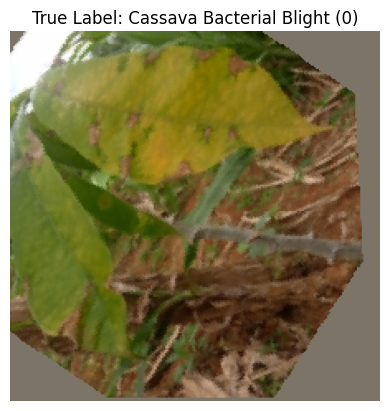

In [ ]:
#  sanity check
dataset = CropDiseaseDataset(OUTPUT_ROOT)
sample_ind = 0
pred_label = None

show_tensor_image(sample_ind,dataset)